In [47]:
import pandas as pd
import numpy as np
from collections import defaultdict
from surprise import accuracy

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

from scipy.sparse import csr_matrix
from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split
from surprise import accuracy


In [24]:
ratings = pd.read_csv("../Data/ml-latest-small/ratings.csv")
movies = pd.read_csv("../Data/ml-latest-small/movies.csv")

In [25]:
ratings.head()



,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [26]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [27]:
df = pd.merge(ratings, movies, on='movieId')
df.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,5,1,4.0,847434962,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
2,7,1,4.5,1106635946,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
3,15,1,2.5,1510577970,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
4,17,1,4.5,1305696483,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 100836 entries, 0 to 100835
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
 4   title      100836 non-null  object 
 5   genres     100836 non-null  object 
dtypes: float64(1), int64(3), object(2)
memory usage: 5.4+ MB


In [29]:
df.isna().sum()

userId       0
movieId      0
rating       0
timestamp    0
title        0
genres       0
dtype: int64

In [30]:
df.shape

(100836, 6)

Users: 610
Movies: 9724


<AxesSubplot:>

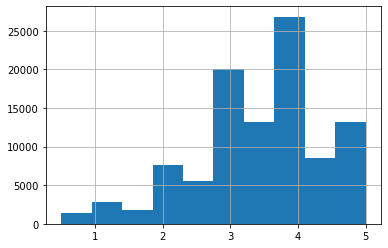

In [31]:
print("Users:", ratings['userId'].nunique())
print("Movies:", ratings['movieId'].nunique())

ratings['rating'].hist()

In [33]:
user_item_matrix = ratings.pivot(index='userId', columns='movieId', values='rating')
user_item_matrix = user_item_matrix.fillna(0)

In [34]:
from sklearn.metrics.pairwise import cosine_similarity

user_similarity = cosine_similarity(user_item_matrix)
user_similarity_df = pd.DataFrame(user_similarity, 
                                  index=user_item_matrix.index, 
                                  columns=user_item_matrix.index)

In [35]:
def recommend_movies(user_id, num_recommendations=5):
    similar_users = user_similarity_df[user_id].sort_values(ascending=False)[1:]
    
    user_ratings = user_item_matrix.loc[user_id]
    unseen_movies = user_ratings[user_ratings == 0]
    
    scores = {}
    
    for movie_id in unseen_movies.index:
        weighted_sum = 0
        similarity_sum = 0
        
        for other_user, similarity in similar_users.items():
            rating = user_item_matrix.loc[other_user, movie_id]
            if rating > 0:
                weighted_sum += similarity * rating
                similarity_sum += similarity
        
        if similarity_sum > 0:
            scores[movie_id] = weighted_sum / similarity_sum
    
    recommended_movies = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    
    top_movies = [movie_id for movie_id, _ in recommended_movies[:num_recommendations]]
    
    return movies[movies['movieId'].isin(top_movies)]

In [36]:
recommend_movies(user_id=1)

,movieId,title,genres
3320,4495,Crossing Delancey (1988),Comedy|Romance
4045,5746,Galaxy of Terror (Quest) (1981),Action|Horror|Mystery|Sci-Fi
4251,6201,Lady Jane (1986),Drama|Romance
4595,6835,Alien Contamination (1980),Action|Horror|Sci-Fi
5906,33649,Saving Face (2004),Comedy|Drama|Romance


In [37]:
train, test = train_test_split(ratings, test_size=0.2, random_state=42)

In [42]:
def predict_rating(user_id, movie_id, k=10):
    # if user or movie not in matrix → can't predict
    if user_id not in user_item_matrix.index:
        return None
    if movie_id not in user_item_matrix.columns:
        return None
    
    # get similarity scores for this user
    sim_scores = user_similarity_df[user_id]
    
    # get ratings for this movie
    movie_ratings = user_item_matrix[movie_id]
    
    # combine into one dataframe
    df = pd.DataFrame({
        'similarity': sim_scores,
        'rating': movie_ratings
    })
    
    # remove users who haven't rated the movie
    df = df[df['rating'] > 0]
    
    # remove the user themself
    df = df.drop(user_id, errors='ignore')
    
    # take top k similar users
    df = df.sort_values(by='similarity', ascending=False).head(k)
    
    # weighted average
    if df['similarity'].sum() == 0:
        return None
    
    pred = np.dot(df['similarity'], df['rating']) / df['similarity'].sum()
    
    return pred

In [43]:
y_true = []
y_pred = []

for row in test.itertuples():
    user = row.userId
    movie = row.movieId
    actual_rating = row.rating
    
    if user in user_item_matrix.index and movie in user_item_matrix.columns:
        pred_rating = predict_rating(user, movie)  # your function
        
        if pred_rating is not None:
            y_true.append(actual_rating)
            y_pred.append(pred_rating)

In [44]:
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 0.9639679501003924
MAE: 0.7441700626942703


In [45]:
def precision_at_k(recommended, relevant, k=5):
    recommended_k = recommended[:k]
    return len(set(recommended_k) & set(relevant)) / k

In [46]:
relevant_movies = test[test['rating'] >= 4]['movieId']

In [48]:
reader = Reader(rating_scale=(0.5, 5))

data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)

trainset, testset = train_test_split(data, test_size=0.2)

model = SVD()
model.fit(trainset)

predictions = model.test(testset)

rmse = accuracy.rmse(predictions)
mae = accuracy.mae(predictions)

RMSE: 0.8755
MAE:  0.6748


In [49]:
def recommend_svd(user_id, movies, ratings, model, n=5):
    all_movies = movies['movieId'].unique()
    rated_movies = ratings[ratings['userId'] == user_id]['movieId']
    
    unseen_movies = [m for m in all_movies if m not in rated_movies.values]
    
    predictions = []
    
    for movie in unseen_movies:
        pred = model.predict(user_id, movie)
        predictions.append((movie, pred.est))
    
    predictions.sort(key=lambda x: x[1], reverse=True)
    
    top_movies = [movie for movie, _ in predictions[:n]]
    
    return movies[movies['movieId'].isin(top_movies)]

In [52]:
pip install streamlit

ERROR: Exception:
Traceback (most recent call last):


  File "c:\Users\jnyak\anaconda3\anacondayesss\envs\learn-env\lib\site-packages\pip\_vendor\urllib3\response.py", line 437, in _error_catcher
    yield
  File "c:\Users\jnyak\anaconda3\anacondayesss\envs\learn-env\lib\site-packages\pip\_vendor\urllib3\response.py", line 519, in read
    data = self._fp.read(amt) if not fp_closed else b""
  File "c:\Users\jnyak\anaconda3\anacondayesss\envs\learn-env\lib\site-packages\pip\_vendor\cachecontrol\filewrapper.py", line 62, in read
    data = self.__fp.read(amt)
  File "c:\Users\jnyak\anaconda3\anacondayesss\envs\learn-env\lib\http\client.py", line 458, in read
    n = self.readinto(b)
  File "c:\Users\jnyak\anaconda3\anacondayesss\envs\learn-env\lib\http\client.py", line 502, in readinto
    n = self.fp.readinto(b)
  File "c:\Users\jnyak\anaconda3\anacondayesss\envs\learn-env\lib\socket.py", line 669, in readinto
    return self._sock.recv_into(b)
  File "c:\Users\jnyak\anaconda3\anacondayesss\envs\learn-env\lib\ssl.py", line 1241, in recv_in

In [54]:
import streamlit as st
import pandas as pd
import numpy as np

# -------------------------------
# Load Data
# -------------------------------
@st.cache_data
def load_data():
    ratings = pd.read_csv("ml-latest-small/ratings.csv")
    movies = pd.read_csv("ml-latest-small/movies.csv")
    return ratings, movies

ratings, movies = load_data()

# -------------------------------
# Build User-Item Matrix
# -------------------------------
user_item_matrix = ratings.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
).fillna(0)

# -------------------------------
# Compute Similarity
# -------------------------------
from sklearn.metrics.pairwise import cosine_similarity

user_similarity = cosine_similarity(user_item_matrix)
user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_item_matrix.index,
    columns=user_item_matrix.index
)

# -------------------------------
# Recommendation Function
# -------------------------------
def recommend_movies(user_id, n=5):
    if user_id not in user_item_matrix.index:
        return []

    similar_users = user_similarity_df[user_id].sort_values(ascending=False)[1:]
    
    user_ratings = user_item_matrix.loc[user_id]
    unseen_movies = user_ratings[user_ratings == 0]
    
    scores = {}

    for movie_id in unseen_movies.index:
        weighted_sum = 0
        sim_sum = 0
        
        for other_user, similarity in similar_users.items():
            rating = user_item_matrix.loc[other_user, movie_id]
            if rating > 0:
                weighted_sum += similarity * rating
                sim_sum += similarity
        
        if sim_sum > 0:
            scores[movie_id] = weighted_sum / sim_sum

    ranked_movies = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    top_movies = [movie_id for movie_id, _ in ranked_movies[:n]]

    return movies[movies['movieId'].isin(top_movies)][['title', 'genres']]

# -------------------------------
# UI
# -------------------------------
st.title("🎬 Movie Recommendation System")

st.write("Get personalized movie recommendations using collaborative filtering.")

# User selection
user_id = st.number_input("Enter User ID", min_value=1, max_value=int(ratings['userId'].max()), step=1)

if st.button("Recommend Movies"):
    recommendations = recommend_movies(user_id)

    if len(recommendations) == 0:
        st.write("No recommendations available for this user.")
    else:
        st.subheader("Top 5 Recommendations:")
        st.table(recommendations)

ModuleNotFoundError: No module named 'streamlit'

In [40]:
"""
Evaluation Module
=================
Metrics for the MovieLens recommendation system.

Covers:
  • Rating-prediction accuracy  → RMSE, MAE
  • Ranking quality             → Precision@K, Recall@K, NDCG@K
  • Bias analysis               → per-rating-count bucket

All functions accept a list of Surprise Prediction objects (algo.test(testset)).
"""


# ── 1. Standard Regression Metrics ───────────────────────────────────────────

def compute_rmse(predictions) -> float:
    """Root Mean Squared Error – penalises large errors more than MAE."""
    return accuracy.rmse(predictions, verbose=False)


def compute_mae(predictions) -> float:
    """Mean Absolute Error – easier to interpret: average error in rating units."""
    return accuracy.mae(predictions, verbose=False)


def print_accuracy_report(predictions):
    """Print a tidy accuracy summary."""
    rmse = compute_rmse(predictions)
    mae  = compute_mae(predictions)
    print("\n── Rating-Prediction Accuracy ──────────────────────────────")
    print(f"  RMSE : {rmse:.4f}  (lower is better; ~0.85–0.90 is good on ML-100k)")
    print(f"  MAE  : {mae:.4f}  (lower is better; ~0.65–0.70 is good on ML-100k)")
    print("────────────────────────────────────────────────────────────\n")
    return {"RMSE": rmse, "MAE": mae}


# ── 2. Ranking Metrics ────────────────────────────────────────────────────────

def get_top_n_predictions(predictions, n: int = 5, threshold: float = 3.5):
    """
    Group predictions by user, sort by predicted rating, return top-N per user.

    threshold : minimum true rating to count a movie as 'relevant'
    """
    # Map: user → sorted list of (predicted_rating, true_rating)
    user_preds = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        user_preds[uid].append((est, true_r))

    for uid in user_preds:
        user_preds[uid].sort(key=lambda x: x[0], reverse=True)
        user_preds[uid] = user_preds[uid][:n]

    return user_preds


def precision_recall_at_k(predictions, k: int = 5, threshold: float = 3.5):
    """
    Precision@K  : fraction of recommended items the user actually liked
    Recall@K     : fraction of liked items that appeared in the top-K list

    Returns mean Precision@K and mean Recall@K across all users.
    """
    top_n = get_top_n_predictions(predictions, n=k, threshold=threshold)

    precisions, recalls = [], []
    for uid, user_ratings in top_n.items():
        # Items in top-K that are relevant
        n_rel_and_rec = sum(1 for (_, true_r) in user_ratings if true_r >= threshold)
        # Total relevant items in the full test set for this user
        n_rel         = sum(1 for (_, _, true_r, _, _) in predictions
                            if _ == uid and true_r >= threshold)
        n_rec_k       = len(user_ratings)

        precisions.append(n_rel_and_rec / n_rec_k if n_rec_k else 0)
        recalls.append(n_rel_and_rec / n_rel     if n_rel   else 0)

    return np.mean(precisions), np.mean(recalls)


def ndcg_at_k(predictions, k: int = 5, threshold: float = 3.5):
    """
    Normalised Discounted Cumulative Gain @K.

    Rewards putting highly relevant items at the TOP of the list.
    A score of 1.0 is perfect; 0.0 means nothing relevant was surfaced.
    """
    top_n = get_top_n_predictions(predictions, n=k, threshold=threshold)

    ndcg_scores = []
    for uid, user_ratings in top_n.items():
        # DCG: relevance / log2(rank+1)
        dcg = sum(
            (1 if true_r >= threshold else 0) / np.log2(rank + 2)
            for rank, (_, true_r) in enumerate(user_ratings)
        )
        # Ideal DCG: assume all top-K slots are relevant
        ideal_hits = min(
            k,
            sum(1 for (_, _, true_r, _, _) in predictions
                if _ == uid and true_r >= threshold)
        )
        idcg = sum(1 / np.log2(rank + 2) for rank in range(ideal_hits))
        ndcg_scores.append(dcg / idcg if idcg > 0 else 0)

    return np.mean(ndcg_scores)


def print_ranking_report(predictions, k: int = 5, threshold: float = 3.5):
    """Print a tidy ranking-quality summary."""
    precision, recall = precision_recall_at_k(predictions, k=k, threshold=threshold)
    ndcg              = ndcg_at_k(predictions, k=k, threshold=threshold)

    print(f"── Ranking Quality  (K={k}, relevance threshold={threshold}) ────────")
    print(f"  Precision@{k} : {precision:.4f}  "
          f"(of the {k} recommended, this fraction the user liked)")
    print(f"  Recall@{k}    : {recall:.4f}  "
          f"(of all liked movies, this fraction was in top-{k})")
    print(f"  NDCG@{k}      : {ndcg:.4f}  "
          f"(1.0 = perfect ranking; ~0.35–0.50 typical on ML-100k)")
    print("────────────────────────────────────────────────────────────\n")
    return {"Precision@K": precision, "Recall@K": recall, "NDCG@K": ndcg}


# ── 3. Bias Analysis by Rating-Count Bucket ───────────────────────────────────

def error_by_rating_count(predictions, ratings_df: pd.DataFrame,
                           buckets=(5, 20, 50, 100)):
    """
    Compute MAE broken down by how many ratings a movie has.
    Helps diagnose the long-tail problem: does the model perform worse
    on less-popular (cold-start) items?
    """
    count_map = ratings_df.groupby("movieId")["rating"].count().to_dict()

    rows = []
    for uid, iid, true_r, est, _ in predictions:
        count = count_map.get(int(iid), 0)
        rows.append({"movieId": iid, "true": true_r, "pred": est, "count": count})

    df = pd.DataFrame(rows)
    df["bucket"] = pd.cut(df["count"], bins=[0] + list(buckets) + [np.inf],
                          labels=[f"≤{b}" for b in buckets] + [f">{buckets[-1]}"])
    df["abs_err"] = (df["true"] - df["pred"]).abs()

    summary = (df.groupby("bucket", observed=True)["abs_err"]
               .agg(MAE="mean", count="count")
               .reset_index())

    print("── MAE by Movie Popularity (rating count) ──────────────────")
    print(summary.to_string(index=False))
    print("  → Higher MAE in low-count buckets signals a cold-start problem.\n")
    return summary


# ── 4. Full Evaluation Pipeline ───────────────────────────────────────────────

def full_evaluation(algo, testset, ratings_df: pd.DataFrame,
                    k: int = 5, threshold: float = 3.5):
    """Run all evaluation metrics and return a combined results dict."""
    predictions = algo.test(testset)

    accuracy_metrics = print_accuracy_report(predictions)
    ranking_metrics  = print_ranking_report(predictions, k=k, threshold=threshold)
    error_by_rating_count(predictions, ratings_df)

    return {**accuracy_metrics, **ranking_metrics}